In [7]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

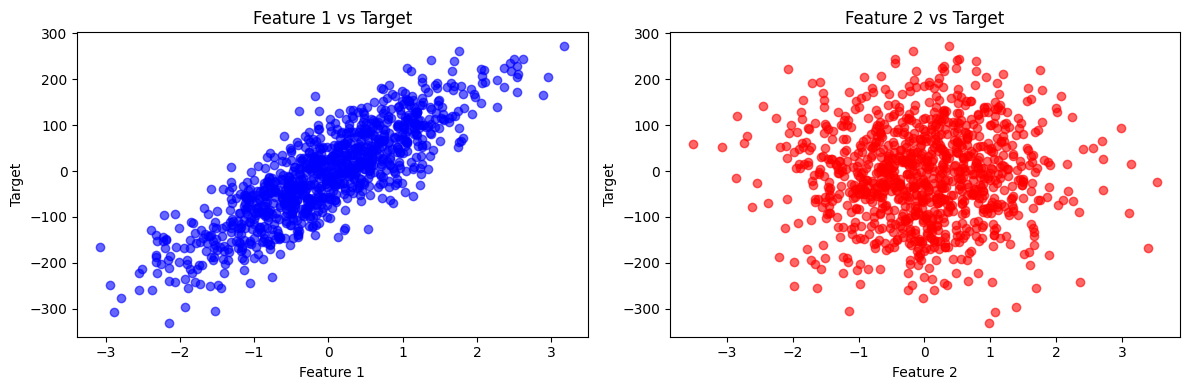

In [8]:
# Generate a more complex regression dataset
X, y = make_regression(n_samples=1000, n_features=5, n_informative=4, noise=1)

# Plot the first two features against the target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X[:, 0], y, alpha=0.6, color='blue')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Target')
axes[0].set_title('Feature 1 vs Target')

axes[1].scatter(X[:, 1], y, alpha=0.6, color='red')
axes[1].set_xlabel('Feature 2')
axes[1].set_ylabel('Target')
axes[1].set_title('Feature 2 vs Target')

plt.tight_layout()
plt.show()

In [9]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train = jnp.array(X_train)
y_train = jnp.array(y_train)
X_test = jnp.array(X_test)
y_test = jnp.array(y_test)

# Print the shapes of the training and testing sets
print(f'Training set shapes: X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'Testing set shapes: X_test: {X_test.shape}, y_test: {y_test.shape}')

Training set shapes: X_train: (800, 5), y_train: (800,)
Testing set shapes: X_test: (200, 5), y_test: (200,)


In [10]:
import jax
import jax.numpy as jnp

def init_params(num_features, key):
    w_key, b_key = jax.random.split(key)
    return {
        "w": jax.random.normal(w_key, (num_features,)),
        "b": jax.random.normal(b_key, ())
    }

def predict(params, x):
    return jnp.dot(x, params["w"]) + params["b"]

def loss_fn(params, x, y):
    preds = jax.vmap(predict, in_axes=(None, 0))(params, x)
    return jnp.mean(jnp.square(preds - y))

In [11]:
@jax.jit
def update(params, x, y, lr):
    loss_val, grads = jax.value_and_grad(loss_fn)(params, x, y)
    new_params = jax.tree_util.tree_map(
        lambda p, g: p - lr * g, params, grads
    )
    return new_params, loss_val

key = jax.random.PRNGKey(42)
params = init_params(num_features=5, key=key)
lr = 1e-3

for epoch in range(90000):
    params, loss = update(params, X_train, y_train, lr)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {loss:.4f}")

Epoch 0: Loss 10604.5713
Epoch 10: Loss 10183.1992
Epoch 20: Loss 9778.6846
Epoch 30: Loss 9390.3457
Epoch 40: Loss 9017.5322
Epoch 50: Loss 8659.6182
Epoch 60: Loss 8316.0078
Epoch 70: Loss 7986.1216
Epoch 80: Loss 7669.4116
Epoch 90: Loss 7365.3447
Epoch 100: Loss 7073.4141
Epoch 110: Loss 6793.1318
Epoch 120: Loss 6524.0312
Epoch 130: Loss 6265.6626
Epoch 140: Loss 6017.5942
Epoch 150: Loss 5779.4141
Epoch 160: Loss 5550.7256
Epoch 170: Loss 5331.1460
Epoch 180: Loss 5120.3125
Epoch 190: Loss 4917.8726
Epoch 200: Loss 4723.4917
Epoch 210: Loss 4536.8447
Epoch 220: Loss 4357.6245
Epoch 230: Loss 4185.5308
Epoch 240: Loss 4020.2791
Epoch 250: Loss 3861.5972
Epoch 260: Loss 3709.2212
Epoch 270: Loss 3562.8984
Epoch 280: Loss 3422.3872
Epoch 290: Loss 3287.4553
Epoch 300: Loss 3157.8801
Epoch 310: Loss 3033.4463
Epoch 320: Loss 2913.9497
Epoch 330: Loss 2799.1924
Epoch 340: Loss 2688.9861
Epoch 350: Loss 2583.1477
Epoch 360: Loss 2481.5044
Epoch 370: Loss 2383.8884
Epoch 380: Loss 2290.

In [12]:
def evaluate_model(model, X_test, y_test):
    preds = jax.vmap(predict, in_axes=(None, 0))(model, X_test)
    mse = jnp.mean(jnp.square(preds - y_test))
    return mse

mse = evaluate_model(params, X_test, y_test)
print(f"Test MSE: {mse:.4f}")

print(f"Learned parameters: w: {params['w']}, b: {params['b']}")

Test MSE: 1.0270
Learned parameters: w: [8.8384239e+01 4.4822052e-02 2.0583693e+01 2.2212164e+01 4.3869713e+01], b: -0.020931242033839226
